<div style="text-align:center;">

# Exploración Inicial — Problema de Clasificación
### *Predicción de la Rotación de Empleados (IBM HR Analytics)*

---
**Universidad de Antioquia — Instituto de Matemáticas**  
*Analítica de Datos — Laboratorio 5*

</div>

---

## Propósito de este notebook

Este notebook desarrolla el **punto 2 del Laboratorio 5 — Exploración Inicial**:

1. Distribución de la variable objetivo `Attrition`.
2. Identificación y cuantificación del desbalance de clases.
3. Caracterización de variables numéricas, ordinales, categóricas y valores faltantes.
4. Establecimiento de las decisiones de preprocesamiento que se replicarán en los notebooks de modelado.

> El **EDA exhaustivo** del dataset ya fue desarrollado en `notebooks/eda_clasificacion.ipynb`. Aquí nos enfocamos exclusivamente en lo que el Laboratorio 5 exige en su fase de exploración previa al modelado.


---
## 1. Importación de librerías y configuración

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns

# ── Estilo visual unificado para todo el notebook ─────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 12,
    "axes.labelsize"    : 10,
    "font.size"         : 10,
    "legend.frameon"    : False,
})
sns.set_palette("tab10")

# ── Paleta consistente para Attrition en todo el proyecto ─────────────────
COLOR_YES = "#e74c3c"   # rojo — renuncia
COLOR_NO  = "#3498db"   # azul — permanece
PALETTE_ATTR = {"Yes": COLOR_YES, "No": COLOR_NO}

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 2. Carga del conjunto de datos

In [2]:
DATA_PATH = Path.cwd().parent.parent / "data" / "raw" / "dataset_clasificacion.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()   # limpieza preventiva de espacios

print(f"Dimensiones: {df.shape[0]:,} observaciones × {df.shape[1]} variables")
df.head()

Dimensiones: 1,470 observaciones × 35 variables


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---
## 3. Distribución de la variable objetivo `Attrition`

La variable objetivo es **binaria**:

- `Yes` → el empleado **renunció** (clase positiva).
- `No`  → el empleado **permanece** en la empresa (clase negativa).

Cuantificamos las dos clases para entender el balance del problema:


In [3]:
conteo = df["Attrition"].value_counts()
proporcion = df["Attrition"].value_counts(normalize=True) * 100

resumen = pd.DataFrame({
    "Conteo"        : conteo,
    "Proporción (%)": proporcion.round(2)
})
print(resumen.to_string())
print(f"\nRazón de desbalance (No : Yes) ≈ {conteo['No']/conteo['Yes']:.2f} : 1")

           Conteo  Proporción (%)
Attrition                        
No           1233           83.88
Yes           237           16.12

Razón de desbalance (No : Yes) ≈ 5.20 : 1


### 3.1 Visualización — Distribución de clases

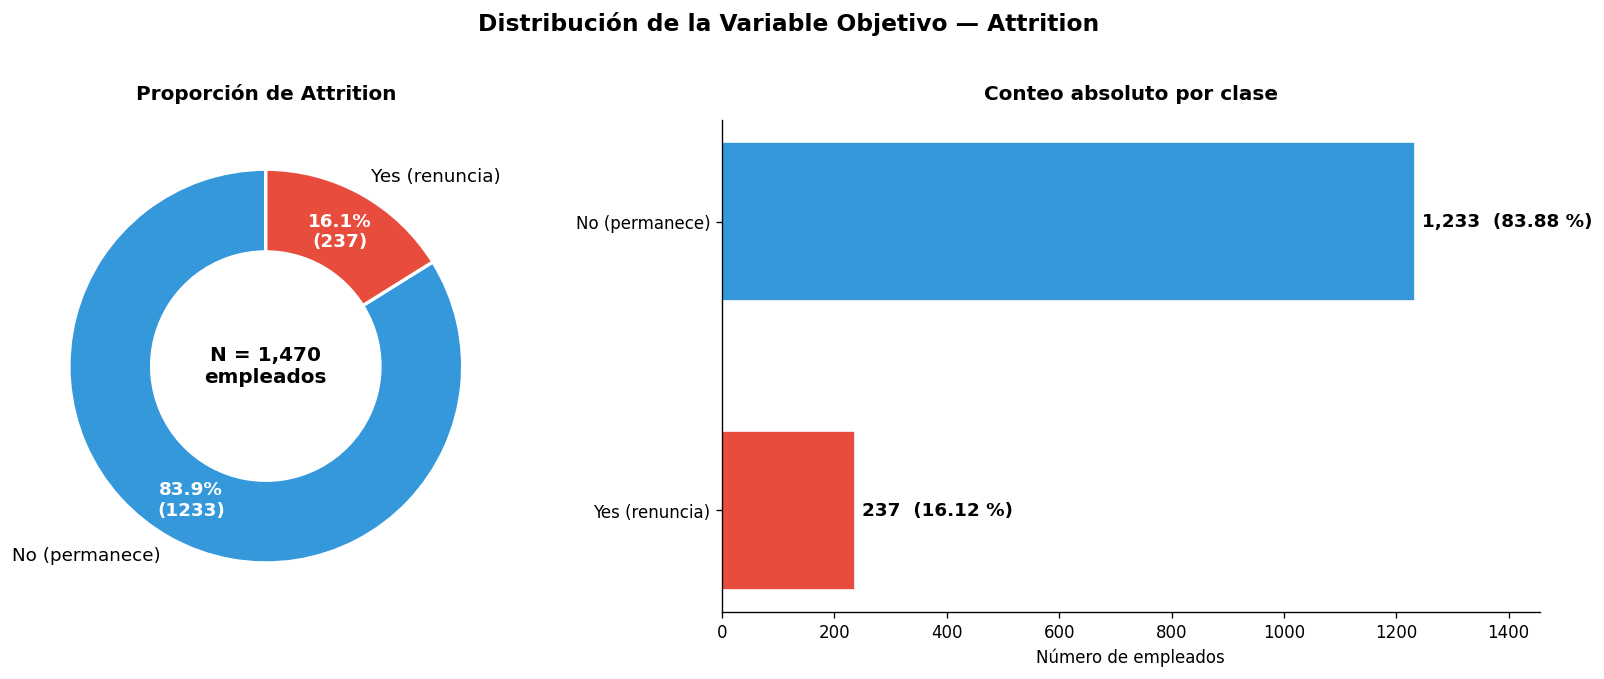

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                         gridspec_kw={"width_ratios": [1, 1.4]})

# ── (a) Donut chart ───────────────────────────────────────────────────────
ax = axes[0]
sizes  = [conteo["No"], conteo["Yes"]]
labels = ["No (permanece)", "Yes (renuncia)"]
colors = [COLOR_NO, COLOR_YES]

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p*sum(sizes)/100))})",
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11)
)
for t in autotexts:
    t.set_color("white")
    t.set_fontweight("bold")

ax.text(0, 0, f"N = {sum(sizes):,}\nempleados",
        ha="center", va="center", fontsize=12, fontweight="bold")
ax.set_title("Proporción de Attrition", pad=12)

# ── (b) Barra horizontal con anotaciones ──────────────────────────────────
ax = axes[1]
bars = ax.barh(labels, sizes, color=colors, edgecolor="white", height=0.55)
for bar, n, p in zip(bars, sizes, [proporcion["No"], proporcion["Yes"]]):
    ax.text(bar.get_width() + 12, bar.get_y() + bar.get_height()/2,
            f"{n:,}  ({p:.2f} %)", va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Número de empleados")
ax.set_xlim(0, max(sizes) * 1.18)
ax.set_title("Conteo absoluto por clase", pad=12)
ax.invert_yaxis()

fig.suptitle("Distribución de la Variable Objetivo — Attrition",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Análisis del desbalance de clases

### 4.1 Diagnóstico cuantitativo

| Métrica                       | Valor    | Interpretación                                                                          |
|:------------------------------|---------:|:----------------------------------------------------------------------------------------|
| Tasa de la clase positiva (Yes) | **16.12 %** | Tasa baja → desbalance moderado-alto.                                                  |
| Razón de desbalance (No : Yes)| ≈ 5.2 : 1 | Por cada renuncia hay cinco permanencias.                                              |
| Tamaño de muestra (N)         | 1 470    | Suficiente para validación cruzada estratificada con $k=5$.                              |
| Tamaño absoluto de la minoría | 237      | Suficiente para entrenar pero exige preservar la estratificación.                       |

### 4.2 Implicaciones para el modelado

1. **Accuracy es engañosa**: un clasificador que prediga siempre `No` alcanzaría ≈ 83.9 % de accuracy sin aprender nada. Por eso el laboratorio exige reportar **Precision, Recall, F1 y AUC** además de Accuracy.
2. **Recall sobre la clase positiva es la métrica crítica**: el costo de no detectar a un empleado en riesgo de renuncia (falso negativo) suele superar el costo de una falsa alarma (falso positivo) en este dominio.
3. **Tratamiento del desbalance**: se aplicará **`class_weight="balanced"`** en los modelos de scikit-learn y **`scale_pos_weight = n_neg / n_pos`** en XGBoost — ambas estrategias re-ponderan la función de pérdida sin alterar la distribución original de los datos, lo que evita fuga de información asociada a métodos de resampling.
4. **Validación cruzada estratificada**: se usará `StratifiedKFold(n_splits=5)` para preservar la proporción $16.1\,/\,83.9$ en cada fold.


### 4.3 Visualización del impacto del desbalance

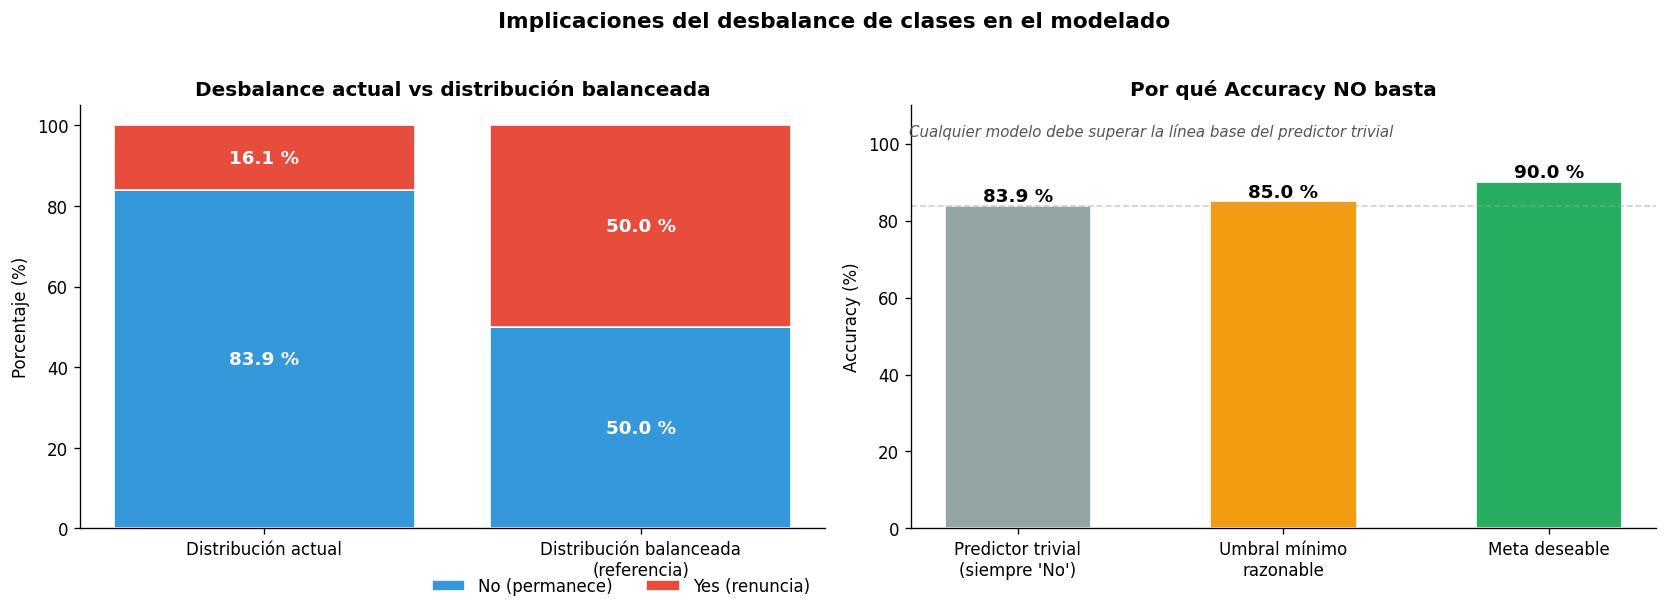

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── (a) Comparación contra un balance ideal ──────────────────────────────
ax = axes[0]
escenarios = ["Distribución actual", "Distribución balanceada\n(referencia)"]
yes_vals = [proporcion["Yes"], 50.0]
no_vals  = [proporcion["No"],  50.0]

bar_no  = ax.bar(escenarios, no_vals,  color=COLOR_NO,  edgecolor="white", label="No (permanece)")
bar_yes = ax.bar(escenarios, yes_vals, bottom=no_vals, color=COLOR_YES, edgecolor="white", label="Yes (renuncia)")

for bars, vals, base in [(bar_no, no_vals, [0,0]), (bar_yes, yes_vals, no_vals)]:
    for b, v, y0 in zip(bars, vals, base):
        ax.text(b.get_x() + b.get_width()/2, y0 + v/2,
                f"{v:.1f} %", ha="center", va="center",
                color="white", fontsize=11, fontweight="bold")

ax.set_ylabel("Porcentaje (%)")
ax.set_ylim(0, 105)
ax.set_title("Desbalance actual vs distribución balanceada")
ax.legend(loc="upper right", bbox_to_anchor=(1.0, -0.08), ncol=2)

# ── (b) Accuracy del "predictor trivial" como baseline ───────────────────
ax = axes[1]
naive_acc = proporcion["No"]
otros = ["Predictor trivial\n(siempre 'No')", "Umbral mínimo\nrazonable", "Meta deseable"]
vals  = [naive_acc, 85, 90]
colors = ["#95a5a6", "#f39c12", "#27ae60"]

bars = ax.bar(otros, vals, color=colors, edgecolor="white", width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.2,
            f"{v:.1f} %", ha="center", fontsize=11, fontweight="bold")

ax.axhline(naive_acc, color="#95a5a6", ls="--", lw=1, alpha=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Por qué Accuracy NO basta")
ax.text(0.5, 102,
        "Cualquier modelo debe superar la línea base del predictor trivial",
        fontsize=9, style="italic", color="#555",
        ha="center", transform=ax.transData)

fig.suptitle("Implicaciones del desbalance de clases en el modelado",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Identificación del tipo de variables

A partir del diccionario de variables (ver `data/Documentanción_clasificación.md`) y el EDA previo, clasificamos las **35 columnas** del dataset en cuatro grupos:

| Grupo                       | Tratamiento que recibirán       |
|:----------------------------|:--------------------------------|
| **Constantes / Identificador** | **Eliminar** (no aportan información) |
| **Categóricas nominales**   | One-Hot Encoding                |
| **Ordinales (numéricas)**   | Conservar como numéricas (el orden tiene significado) |
| **Numéricas continuas / discretas** | Estandarización (StandardScaler) |


In [6]:
# ── Clasificación de variables ────────────────────────────────────────────
COLS_DESCARTAR = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]

COLS_NOMINALES = ["BusinessTravel", "Department", "EducationField",
                  "Gender", "JobRole", "MaritalStatus", "OverTime"]

COLS_ORDINALES = ["Education", "EnvironmentSatisfaction", "JobInvolvement",
                  "JobLevel", "JobSatisfaction", "PerformanceRating",
                  "RelationshipSatisfaction", "StockOptionLevel", "WorkLifeBalance"]

COLS_NUMERICAS = ["Age", "DailyRate", "DistanceFromHome", "HourlyRate",
                  "MonthlyIncome", "MonthlyRate", "NumCompaniesWorked",
                  "PercentSalaryHike", "TotalWorkingYears", "TrainingTimesLastYear",
                  "YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion",
                  "YearsWithCurrManager"]

# Verificación: el conjunto debe cubrir TODAS las columnas (incluido el target)
TARGET = "Attrition"
cubiertas = set(COLS_DESCARTAR + COLS_NOMINALES + COLS_ORDINALES + COLS_NUMERICAS + [TARGET])
faltantes  = set(df.columns) - cubiertas
sobrantes  = cubiertas - set(df.columns)

assert not faltantes, f"Columnas no clasificadas: {faltantes}"
assert not sobrantes, f"Columnas inexistentes en df: {sobrantes}"

print(f"  Variable objetivo            : 1   → {TARGET}")
print(f"  Columnas a descartar         : {len(COLS_DESCARTAR):>2}  → {COLS_DESCARTAR}")
print(f"  Variables nominales (OHE)    : {len(COLS_NOMINALES):>2}  → {COLS_NOMINALES}")
print(f"  Variables ordinales          : {len(COLS_ORDINALES):>2}")
print(f"  Variables numéricas (Scaler) : {len(COLS_NUMERICAS):>2}")
print(f"  ─" * 25)
print(f"  Total features efectivas     : {len(COLS_NOMINALES)+len(COLS_ORDINALES)+len(COLS_NUMERICAS):>2}")

  Variable objetivo            : 1   → Attrition
  Columnas a descartar         :  4  → ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
  Variables nominales (OHE)    :  7  → ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
  Variables ordinales          :  9
  Variables numéricas (Scaler) : 14
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  Total features efectivas     : 30


---
## 6. Valores faltantes y columnas constantes

In [7]:
# ── 6.1 Verificación de valores faltantes ────────────────────────────────
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0]

if faltantes.empty:
    print("  ✓ El dataset no contiene valores faltantes.")
else:
    print("Columnas con valores faltantes:")
    print(faltantes.to_string())

# ── 6.2 Verificación de columnas constantes ──────────────────────────────
constantes = {c: df[c].unique().tolist() for c in df.columns if df[c].nunique() == 1}

print("\nColumnas con un único valor (sin variabilidad):")
for c, v in constantes.items():
    print(f"  · {c:<16s} → {v}")

print("\n  ✓ Estas variables se eliminan por no aportar información discriminativa.")

  ✓ El dataset no contiene valores faltantes.

Columnas con un único valor (sin variabilidad):
  · EmployeeCount    → [1]
  · Over18           → ['Y']
  · StandardHours    → [80]

  ✓ Estas variables se eliminan por no aportar información discriminativa.


---
## 7. Caracterización de variables numéricas

Estadísticas descriptivas y comparación entre las dos clases del objetivo. Las variables cuyo valor medio difiera apreciablemente entre `Yes` y `No` son candidatas naturales a tener poder predictivo.


In [8]:
num_all = COLS_ORDINALES + COLS_NUMERICAS

desc = df[num_all].agg(["mean", "median", "std", "min", "max"]).T.round(2)
desc.columns = ["Media", "Mediana", "Desv. Estándar", "Mín", "Máx"]
desc.index.name = "Variable"
desc

,Media,Mediana,Desv. Estándar,Mín,Máx
Variable,,,,,
Education,2.91,3.0,1.02,1.0,5.0
EnvironmentSatisfaction,2.72,3.0,1.09,1.0,4.0
JobInvolvement,2.73,3.0,0.71,1.0,4.0
JobLevel,2.06,2.0,1.11,1.0,5.0
JobSatisfaction,2.73,3.0,1.10,1.0,4.0
PerformanceRating,3.15,3.0,0.36,3.0,4.0
RelationshipSatisfaction,2.71,3.0,1.08,1.0,4.0
StockOptionLevel,0.79,1.0,0.85,0.0,3.0
WorkLifeBalance,2.76,3.0,0.71,1.0,4.0


In [9]:
# Diferencia de medias por clase y test de Welch (no asume varianzas iguales)
from scipy import stats

resumen_num = []
for col in num_all:
    a = df.loc[df["Attrition"] == "Yes", col]
    b = df.loc[df["Attrition"] == "No",  col]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    resumen_num.append({
        "Variable"    : col,
        "Media Yes"   : a.mean(),
        "Media No"    : b.mean(),
        "Δ (Yes − No)": a.mean() - b.mean(),
        "p-valor"     : p,
        "Significativa (α=0.05)": p < 0.05,
    })

tabla_num = pd.DataFrame(resumen_num)
tabla_num["|Δ relativo|"] = (
    (tabla_num["Δ (Yes − No)"].abs() / tabla_num["Media No"].abs()) * 100
).round(2)

tabla_num = tabla_num.sort_values("p-valor").round(4)
tabla_num.reset_index(drop=True, inplace=True)
tabla_num

,Variable,Media Yes,Media No,Δ (Yes − No),p-valor,Significativa (α=0.05),|Δ relativo|
0,MonthlyIncome,4787.0928,6832.7397,-2045.6468,0.0000,True,29.94
1,JobLevel,1.6371,2.1460,-0.5089,0.0000,True,23.71
2,TotalWorkingYears,8.2447,11.8629,-3.6182,0.0000,True,30.50
3,YearsInCurrentRole,2.9030,4.4842,-1.5812,0.0000,True,35.26
4,YearsWithCurrManager,2.8523,4.3674,-1.5151,0.0000,True,34.69
5,Age,33.6076,37.5612,-3.9536,0.0000,True,10.53
6,YearsAtCompany,5.1308,7.3690,-2.2382,0.0000,True,30.37
7,StockOptionLevel,0.5274,0.8451,-0.3177,0.0000,True,37.59
8,JobInvolvement,2.5190,2.7705,-0.2515,0.0000,True,9.08
9,JobSatisfaction,2.4684,2.7786,-0.3102,0.0001,True,11.17


### 7.1 Variables numéricas con mayor diferencia entre clases

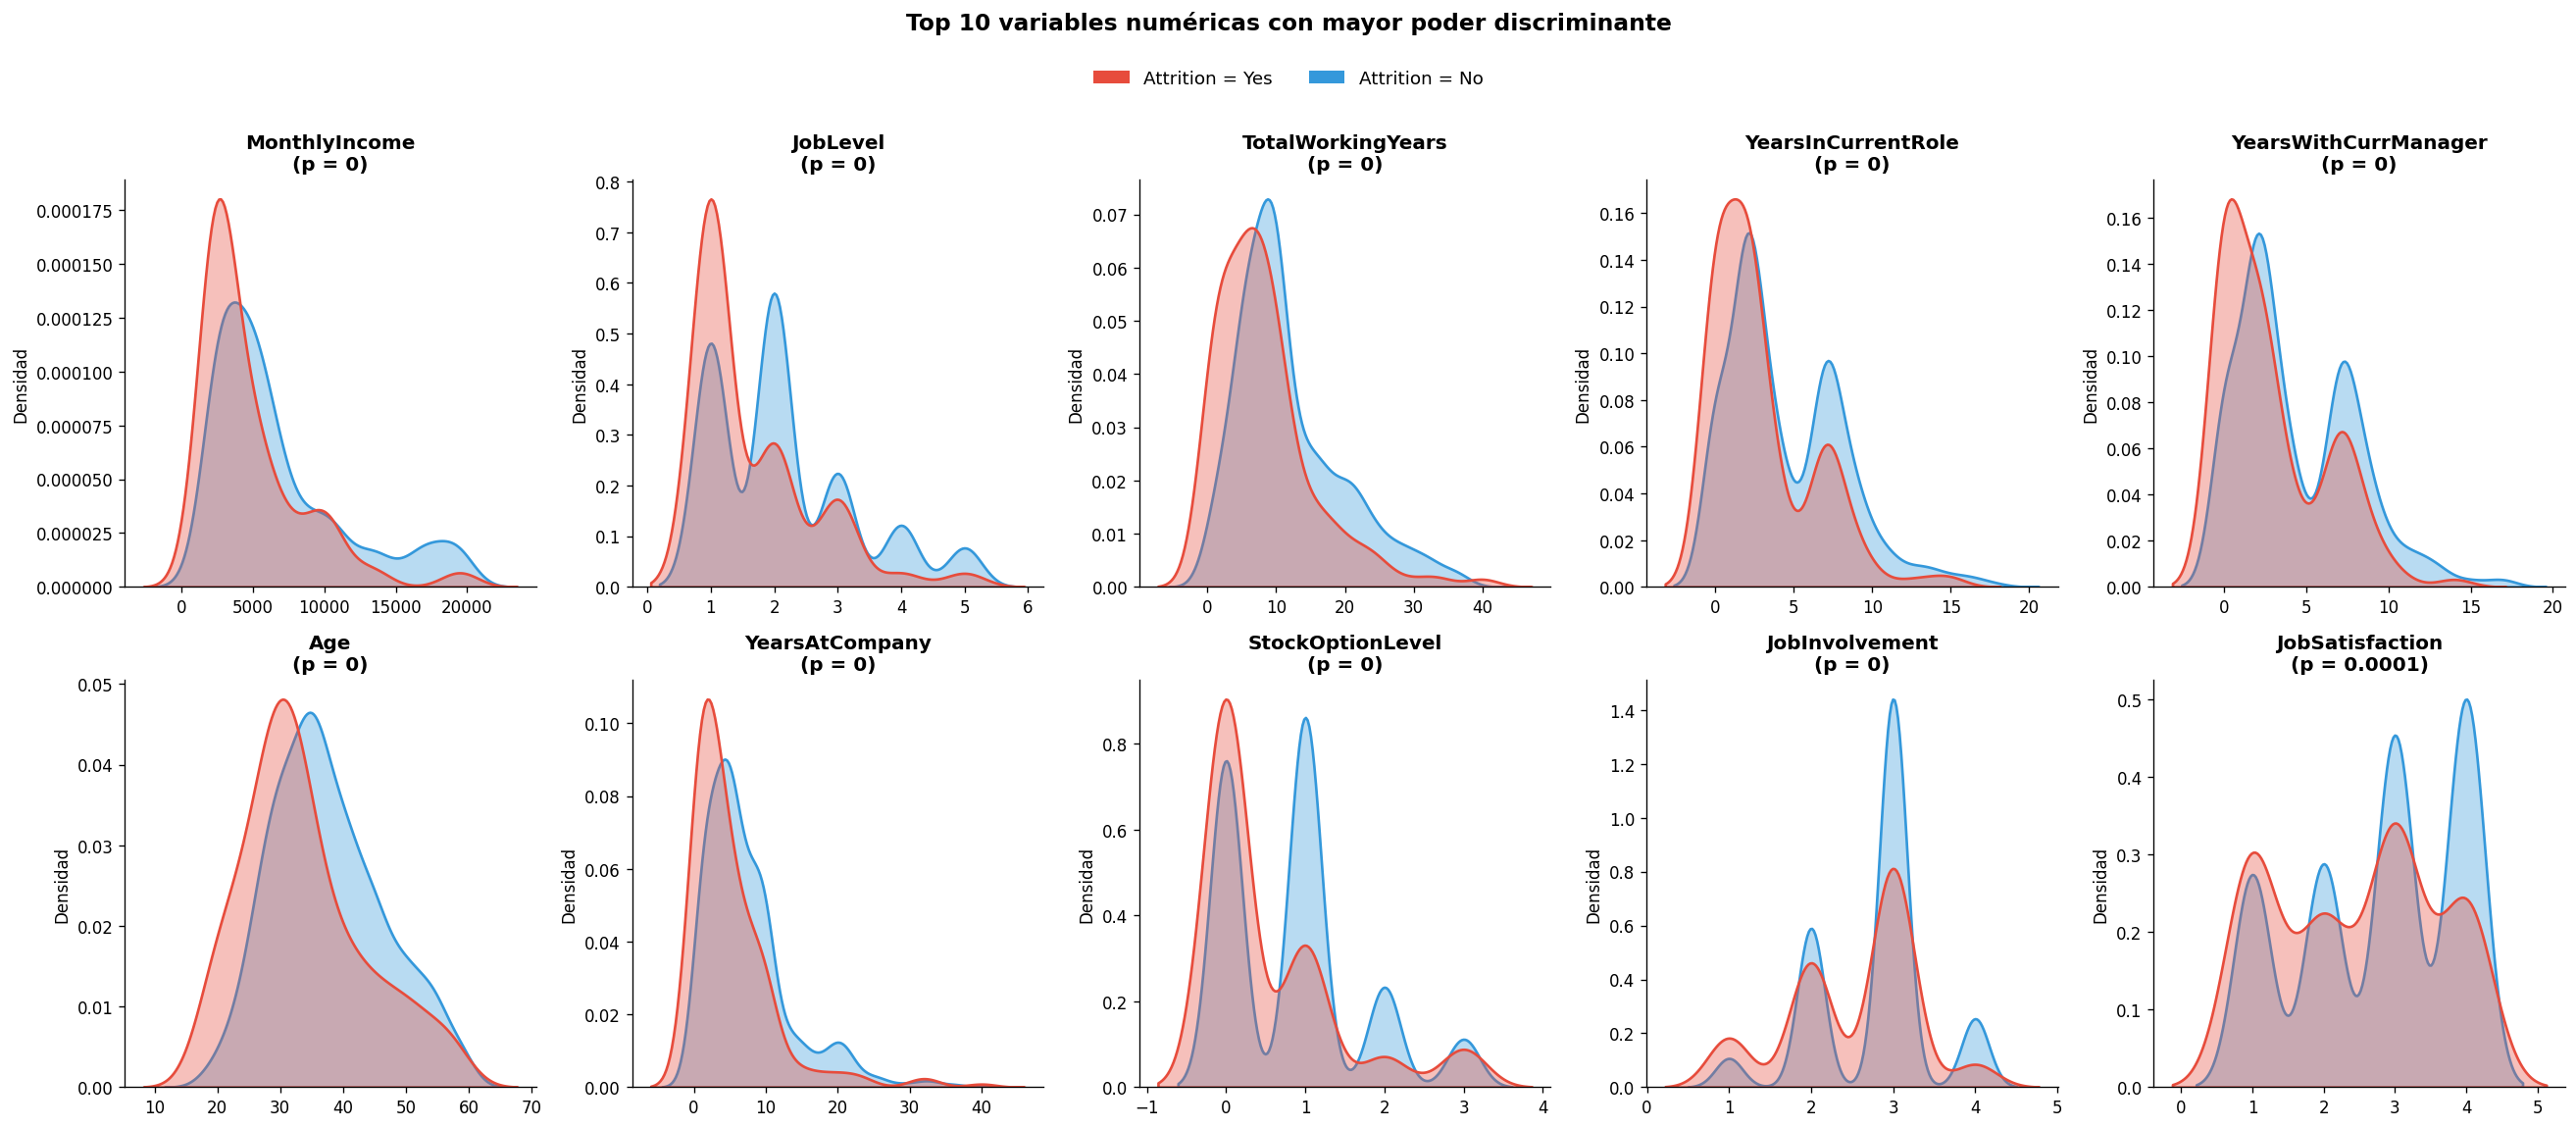

In [10]:
top_n = 10
top_vars = tabla_num.head(top_n)["Variable"].tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for ax, col in zip(axes, top_vars):
    sns.kdeplot(data=df, x=col, hue="Attrition",
                palette=PALETTE_ATTR, fill=True, alpha=0.35,
                common_norm=False, ax=ax, linewidth=1.6)
    p_val = tabla_num.loc[tabla_num["Variable"] == col, "p-valor"].values[0]
    ax.set_title(f"{col}\n(p = {p_val:.4g})")
    ax.set_xlabel("")
    ax.set_ylabel("Densidad")
    if ax.get_legend() is not None:
        ax.get_legend().set_visible(False)

# Leyenda única
handles = [Patch(facecolor=COLOR_YES, label="Attrition = Yes"),
           Patch(facecolor=COLOR_NO,  label="Attrition = No")]
fig.legend(handles=handles, loc="upper center", ncol=2,
           bbox_to_anchor=(0.5, 1.02), fontsize=11, frameon=False)

fig.suptitle(f"Top {top_n} variables numéricas con mayor poder discriminante",
             fontsize=14, fontweight="bold", y=1.06)
plt.tight_layout()
plt.show()

---
## 8. Caracterización de variables categóricas

Para cada variable nominal mostramos la **tasa de renuncia (`Yes`) por categoría**. Las categorías con tasas alejadas del promedio global $\approx 16.1\%$ son candidatas con poder predictivo.


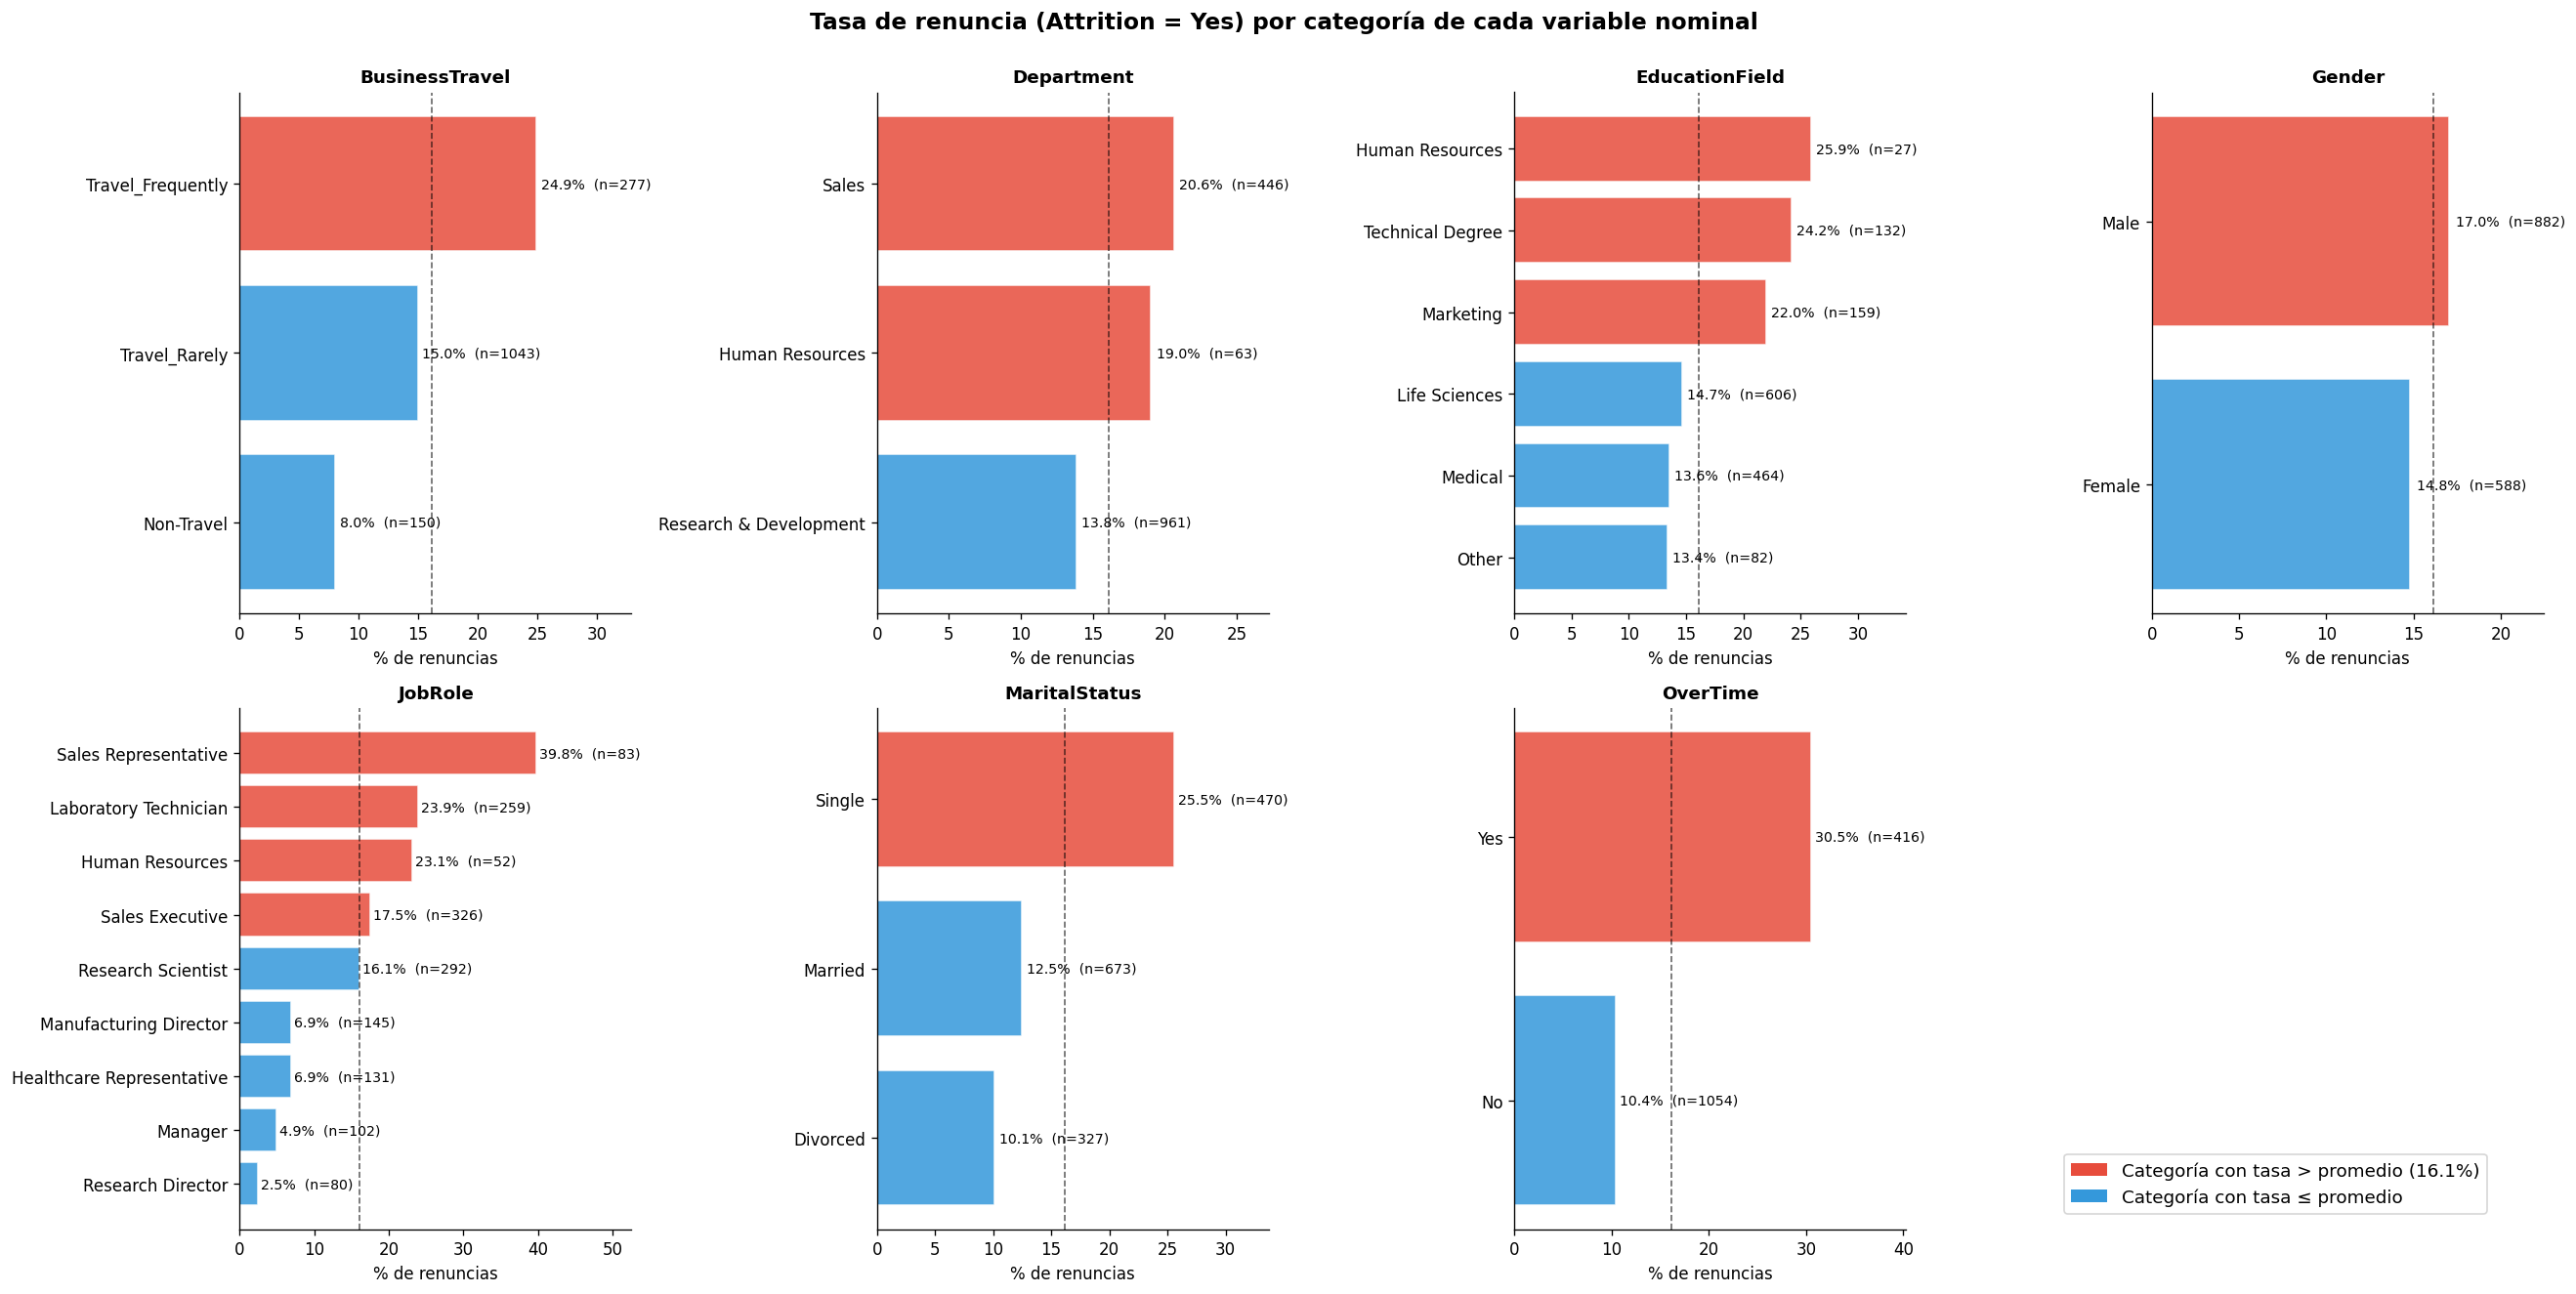

In [11]:
tasa_global = df["Attrition"].eq("Yes").mean()

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for ax, col in zip(axes, COLS_NOMINALES):
    tasa = (df.groupby(col)["Attrition"]
              .apply(lambda s: (s == "Yes").mean() * 100)
              .sort_values(ascending=False))
    n_cat = df[col].value_counts().reindex(tasa.index)

    bars = ax.barh(tasa.index.astype(str), tasa.values,
                   color=[COLOR_YES if v > tasa_global*100 else COLOR_NO for v in tasa.values],
                   alpha=0.85, edgecolor="white")
    for b, v, n in zip(bars, tasa.values, n_cat.values):
        ax.text(b.get_width() + 0.4, b.get_y() + b.get_height()/2,
                f"{v:.1f}%  (n={n})", va="center", fontsize=8.5)

    ax.axvline(tasa_global*100, color="black", ls="--", lw=1, alpha=0.6)
    ax.set_xlim(0, tasa.max() * 1.32)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("% de renuncias")
    ax.invert_yaxis()

# Ocultar último eje
axes[-1].set_visible(False)

handles = [
    Patch(facecolor=COLOR_YES, label=f"Categoría con tasa > promedio ({tasa_global*100:.1f}%)"),
    Patch(facecolor=COLOR_NO,  label="Categoría con tasa ≤ promedio"),
]
fig.legend(handles=handles, loc="lower right", bbox_to_anchor=(0.97, 0.06),
           fontsize=11, frameon=True, fancybox=True)

fig.suptitle("Tasa de renuncia (Attrition = Yes) por categoría de cada variable nominal",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

---
## 9. Decisiones de preprocesamiento

Las siguientes decisiones se aplicarán **idénticamente** en los notebooks de modelado, dentro de un `Pipeline` de scikit-learn (para evitar fuga de información durante la validación cruzada):

| # | Paso                                  | Detalle                                                                                  |
|--:|:--------------------------------------|:-----------------------------------------------------------------------------------------|
| 1 | **Eliminación de variables**          | `EmployeeCount`, `EmployeeNumber`, `Over18`, `StandardHours` (constantes / identificador).|
| 2 | **Codificación variable objetivo**    | `Attrition`: `Yes` → 1, `No` → 0 (clase positiva = renuncia).                            |
| 3 | **One-Hot Encoding (`drop="first"`)** | Aplicado a las 7 variables nominales — evita la trampa de la variable ficticia.          |
| 4 | **Estandarización**                   | `StandardScaler` aplicado a las 23 variables numéricas (ordinales + continuas / discretas). |
| 5 | **Partición Train / Test**            | `test_size=0.30`, `stratify=y`, `random_state=42`.                                       |
| 6 | **Manejo del desbalance**             | `class_weight="balanced"` (sklearn) y `scale_pos_weight=n_neg/n_pos` (XGBoost).           |
| 7 | **Validación cruzada**                | `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`.                            |

> Todos los pasos 3 y 4 quedan encapsulados en un `ColumnTransformer` que será el primer paso de cada `Pipeline`.


---
## 10. Síntesis ejecutiva

- **Tipo de problema**: clasificación binaria supervisada.
- **Variable objetivo**: `Attrition` (Yes / No).
- **Tamaño**: 1 470 observaciones, 30 features efectivas.
- **Desbalance**: 16.1 % (Yes) vs 83.9 % (No), razón ≈ 5.2 : 1 — **moderado-alto**, exige tratamiento explícito.
- **Calidad de datos**: sin valores faltantes; 4 columnas inútiles ya identificadas.
- **Métrica prioritaria**: **Recall** sobre la clase `Yes` (un falso negativo cuesta más que un falso positivo en el dominio de retención de talento), complementada por **F1** y **AUC** para evaluar el compromiso global.
- **Próximos notebooks**: cada modelo se construye en un notebook independiente — el preprocesamiento aquí definido se replica exactamente, dentro de un `Pipeline`, garantizando comparabilidad y ausencia de fuga de información.
